In [185]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


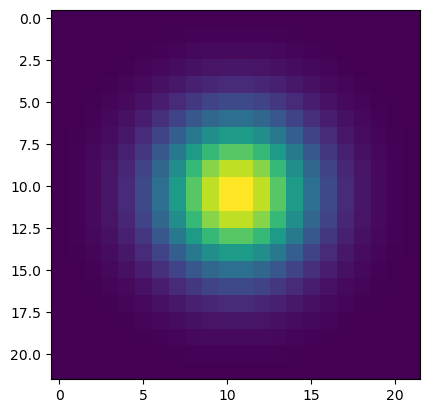

In [186]:
# test Kernel constructor

psf_pars={'sx':0.3,'sy':0.3,'angle':0}
kernel_shape=[22,22]
plt.imshow(blurtool.Kernel(kernel_shape,mode='gaussian',psf_pars=psf_pars)())

kernel.shape= torch.Size([22, 22])


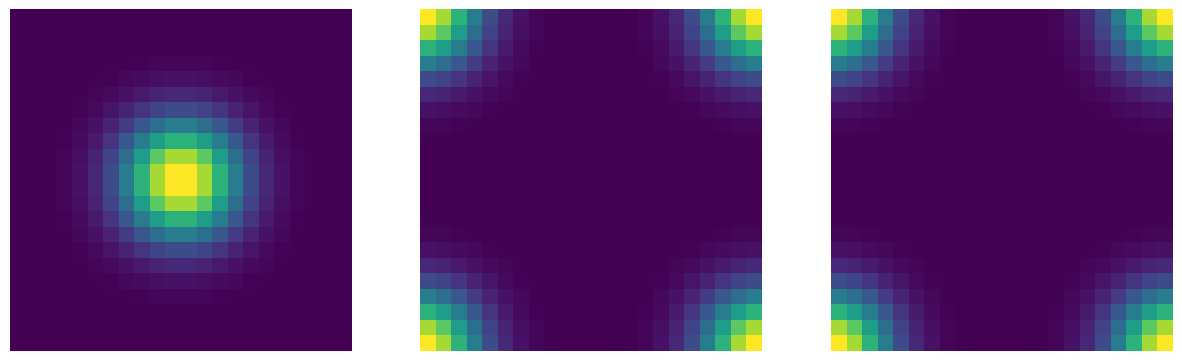

In [187]:
# cshift function

psf_pars={'sx':0.25,'sy':0.25,'angle':0}
kernel_shape=[22,22]
kernel=blurtool.Kernel(kernel_shape,mode='gaussian',psf_pars=psf_pars)()

fig,ax=plt.subplots(1,3,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(kernel)
ax[1].axis('off')
ax[1].imshow(blurtool.cshift(kernel))
ax[2].axis('off')
ax[2].imshow(torch.fft.fftshift(kernel))

print('kernel.shape=',kernel.shape)

kernel.shape= torch.Size([12, 12])
padded_kernel.shape= torch.Size([13, 13])


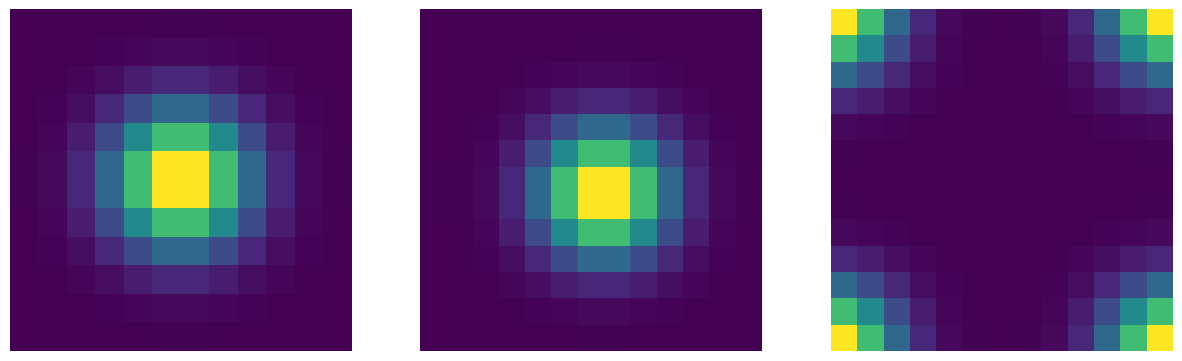

In [188]:
# pad function, and combining pad with cshift 

img_shape=[13,13]
kernel_shape=[12,12]
psf_pars={'sx':0.3,'sy':0.3,'angle':0}
kernel=blurtool.Kernel(kernel_shape,mode='gaussian',psf_pars=psf_pars)()

pad_width=[img_shape[0]-kernel_shape[0],img_shape[1]-kernel_shape[1]]
padded_kernel=blurtool.pad(kernel,pad_width)
shifted_padded_kernel=blurtool.cshift(padded_kernel)

fig,ax=plt.subplots(1,3,figsize=(15,15))
ax[0].axis('off')
ax[0].imshow(kernel)
ax[1].axis('off')
ax[1].imshow(padded_kernel)
ax[2].axis('off')
ax[2].imshow(shifted_padded_kernel);

print('kernel.shape=',kernel.shape)
print('padded_kernel.shape=',padded_kernel.shape)

cropped_kernel.shape= torch.Size([13, 13])


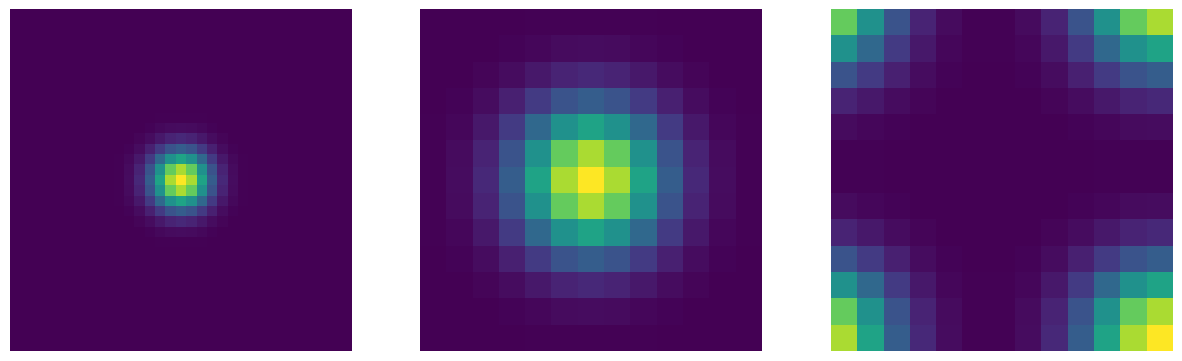

In [189]:
# crop around function

psf_pars={'sx':0.12,'sy':0.12,'angle':0}
kernel=blurtool.Kernel([33,33],mode='gaussian',psf_pars=psf_pars)

fig,ax=plt.subplots(1,3,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(kernel())

cropped_kernel=blurtool.crop_around(kernel(),[13,13],pos=None)
ax[1].axis('off')
ax[1].imshow(cropped_kernel)

ax[2].axis('off')
ax[2].imshow(blurtool.cshift(cropped_kernel))

print('cropped_kernel.shape=',cropped_kernel.shape)

img_shape= torch.Size([256, 256])
forward_timer= 0.005778837017714977  s


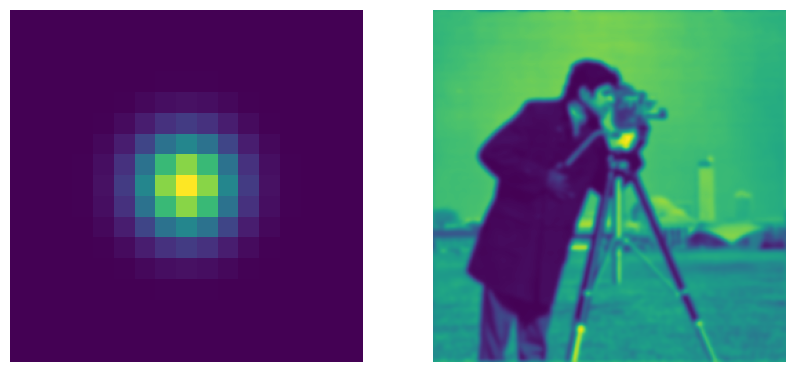

In [190]:
# define a blur object and blur a single image

# open test image
test_image=Image.open('../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)

# define blur model
psf_pars={'sx':0.2,'sy':0.2,'angle':0}
kernel_shape=[17,17]
kernel=blurtool.Kernel(kernel_shape,mode='gaussian',psf_pars=psf_pars)()
gblur=blurtool.StationaryBlur(kernel)


fig,ax=plt.subplots(1,2,figsize=(10,5))

ax[0].axis('off')
ax[0].imshow(gblur.kernel())
ax[1].axis('off')
ax[1].imshow(gblur.forward(test_image))

print('forward_timer=',gblur.forward_timer,' s')

test_images.shape= torch.Size([4, 256, 256])
forward_timer= 0.009328633081167936  s


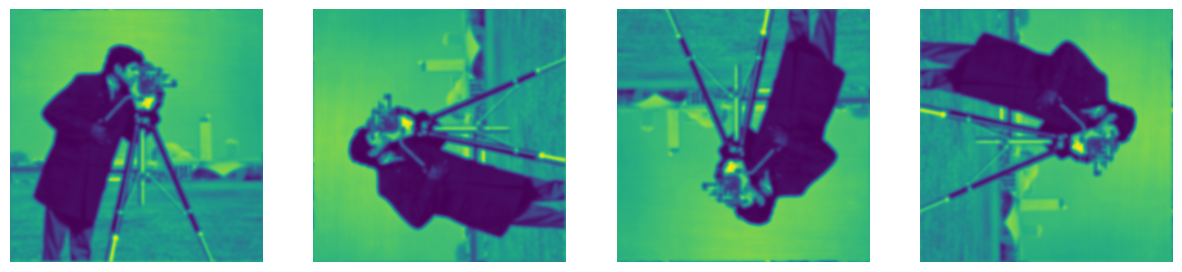

In [191]:
# define a blur object and blur a batch of images 

# open test image
test_images=[Image.open('../data/cameraman.tif').convert('L').rotate(i*90) for i in range(4)]
test_images=torch.stack([torchvision.transforms.ToTensor()(test_images[i]).squeeze() for i in range(4)],dim=0)
print('test_images.shape=',test_images.shape)

# define blur model
psf_pars={'sx':0.1,'sy':0.1,'angle':0}
kernel_shape=[32,32]
kernel=blurtool.Kernel(kernel_shape,mode='gaussian',psf_pars=psf_pars)()
gblur=blurtool.StationaryBlur(kernel)

# calculate blurred version of test images
blurred_test_images=gblur.forward(test_images)

# show timer
print('forward_timer=',gblur.forward_timer,' s')

fig,ax=plt.subplots(1,4,figsize=(15,5))


ax[0].axis('off')
ax[0].imshow(blurred_test_images[0])
ax[1].axis('off')
ax[1].imshow(blurred_test_images[1])
ax[2].axis('off')
ax[2].imshow(blurred_test_images[2])
ax[3].axis('off')
ax[3].imshow(blurred_test_images[3]);

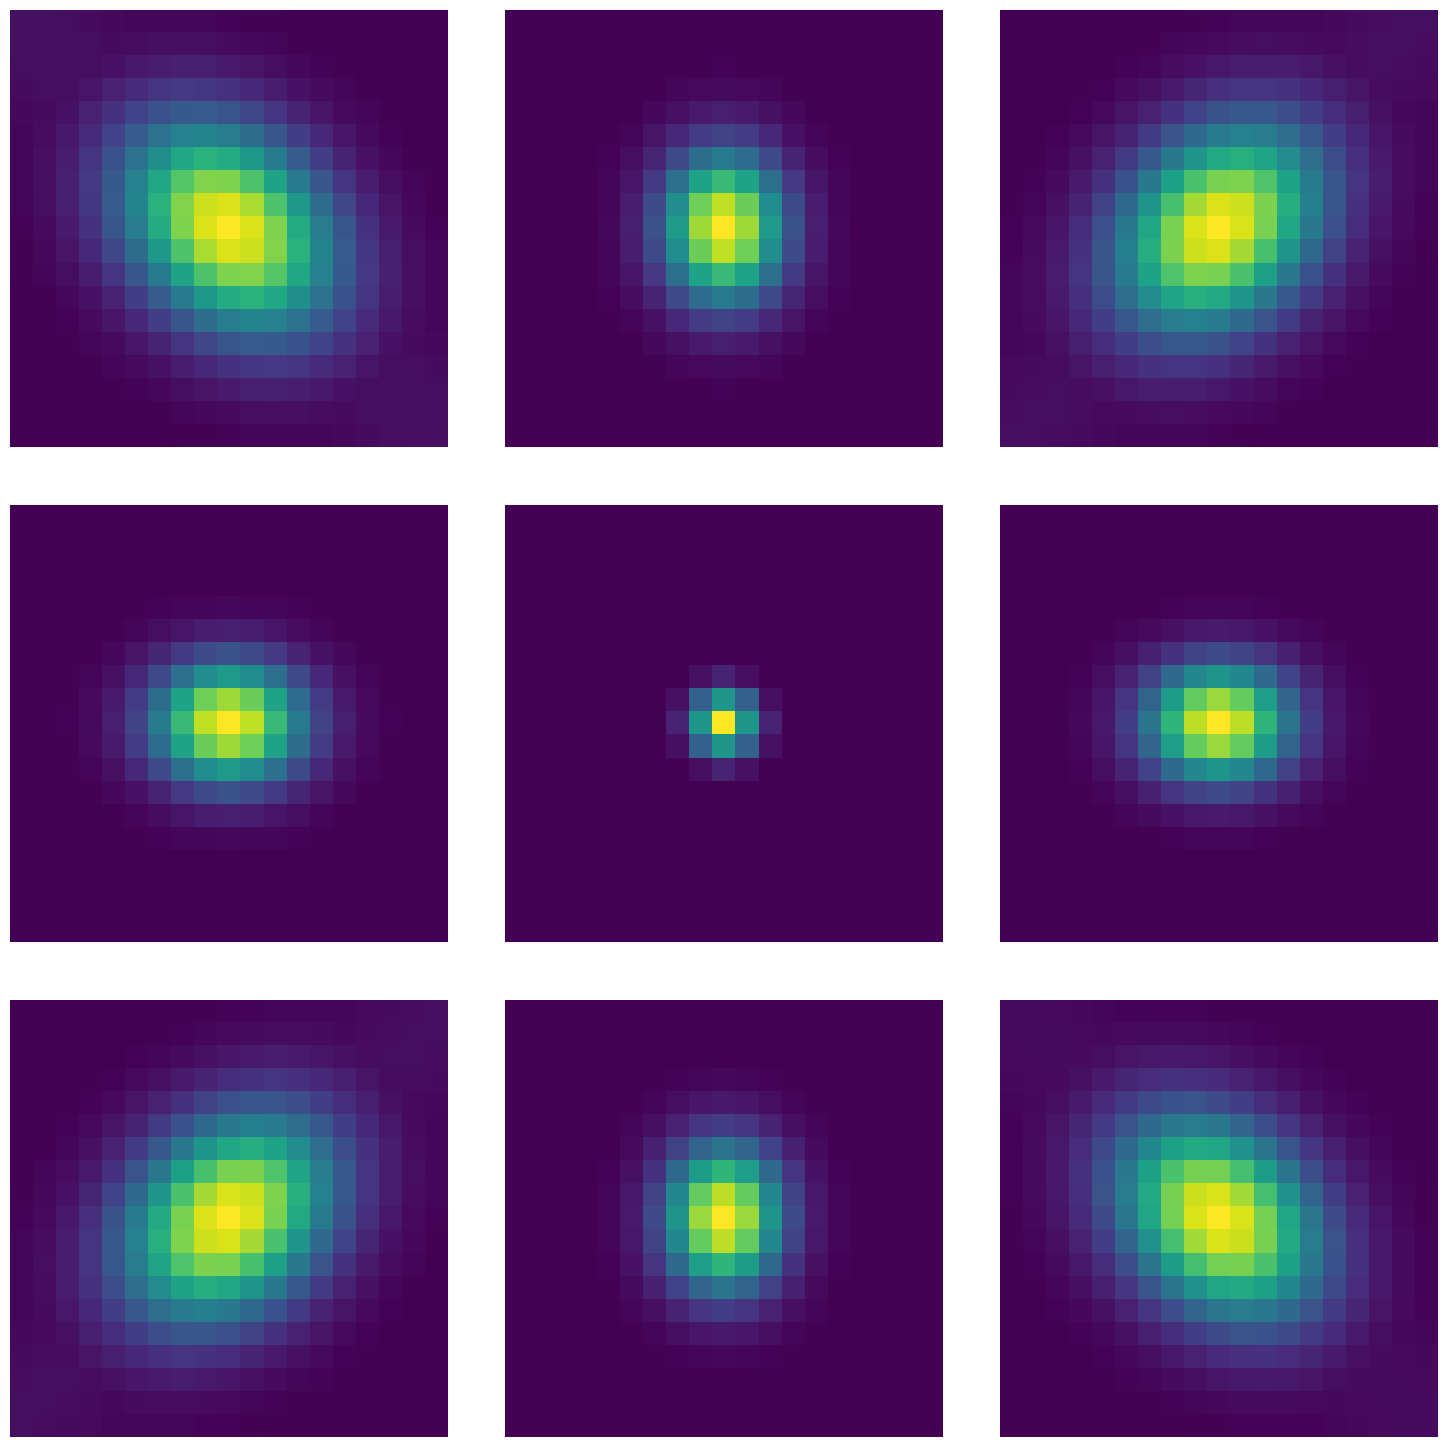

In [192]:
# test RotGaussian lattice model

# define lattice
img_shape=(127,127)
kernel_shape=(19,19)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.3,'by':0.2,'gamma_x':2,'gamma_y':2}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)

fig,ax=plt.subplots(3,3,figsize=(15,15))
fig.tight_layout() 

ax[0,0].axis('off')
ax[0,0].imshow(lat.kernel([0,0])());
ax[0,1].axis('off')
ax[0,1].imshow(lat.kernel([0,63])());
ax[0,2].axis('off')
ax[0,2].imshow(lat.kernel([0,126])());


ax[1,0].axis('off')
ax[1,0].imshow(lat.kernel([63,0])());
ax[1,1].axis('off')
ax[1,1].imshow(lat.kernel([63,63])());
ax[1,2].axis('off')
ax[1,2].imshow(lat.kernel([63,126])());


ax[2,0].axis('off')
ax[2,0].imshow(lat.kernel([126,0])());
ax[2,1].axis('off')
ax[2,1].imshow(lat.kernel([126,63])());
ax[2,2].axis('off')
ax[2,2].imshow(lat.kernel([126,126])());


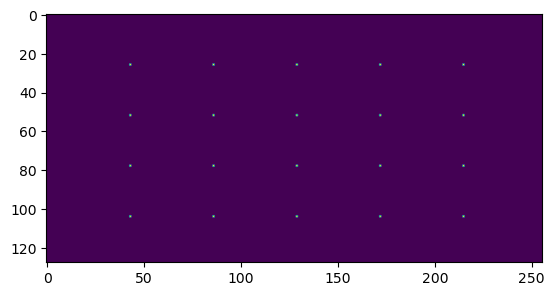

In [193]:
# test lat.grid

# define shapes
sampled_shape=(4,5)
img_shape=(128,256)

lat=blurtool.Lattice(img_shape)
plt.imshow(lat.grid(sampled_shape,blur=False));

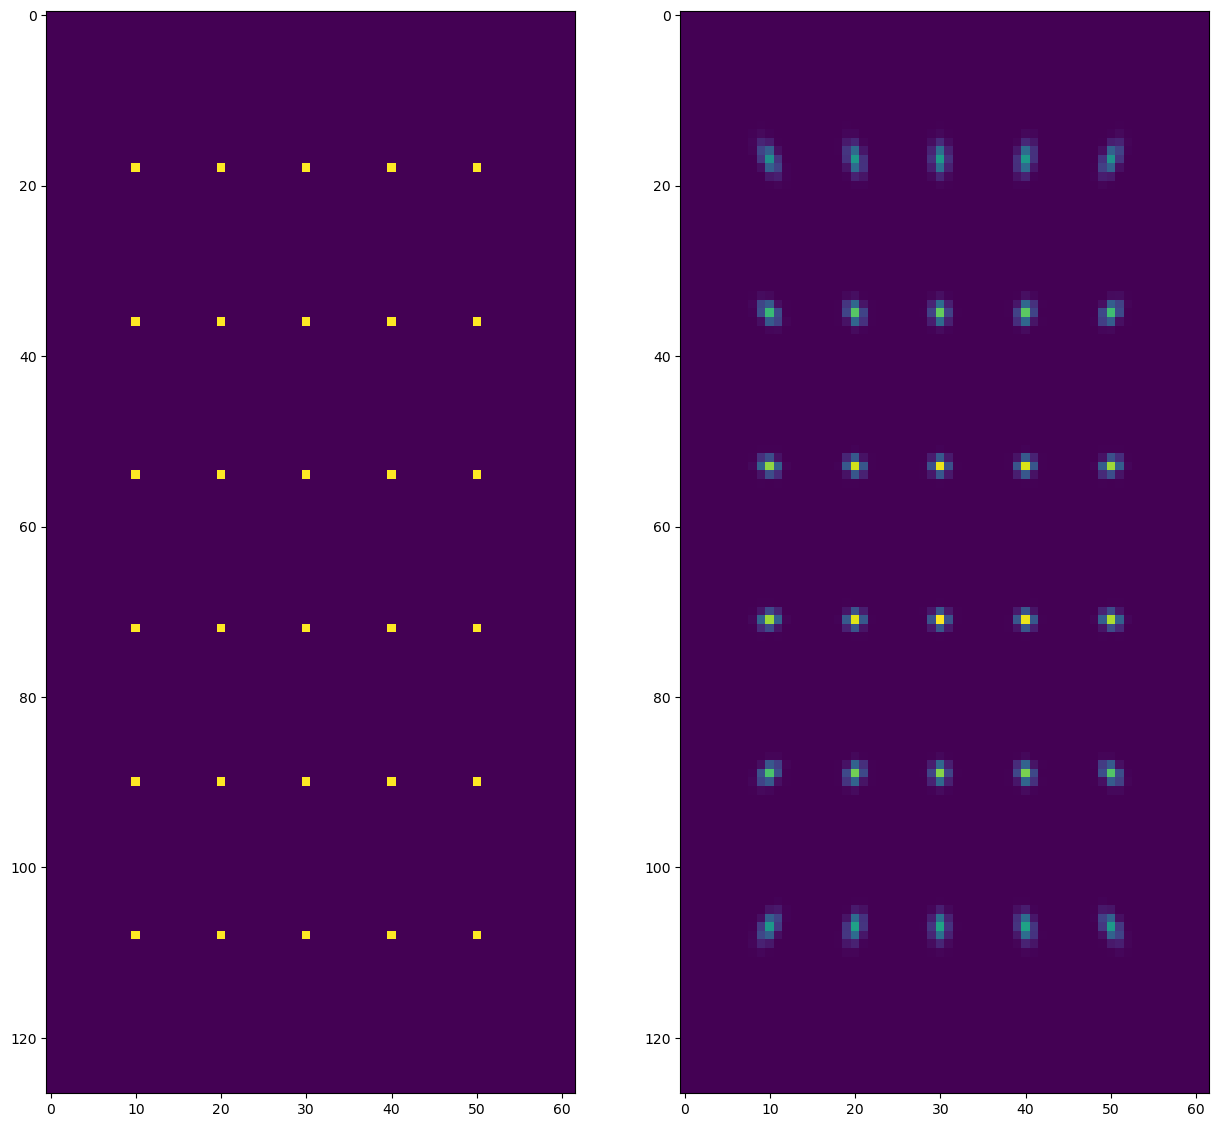

In [194]:
# test lat.grid with blur=True

# define shapes
img_shape=(127,62)
sampled_shape=(6,5)

# define lattice
kernel_shape=(13,13)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.2,'by':0.2,'gamma_x':2,'gamma_y':32}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)

# results
fig,ax=plt.subplots(1,2,figsize=(15,15))

ax[0].imshow(lat.grid(sampled_shape));
ax[1].imshow(lat.grid(sampled_shape,blur=True));

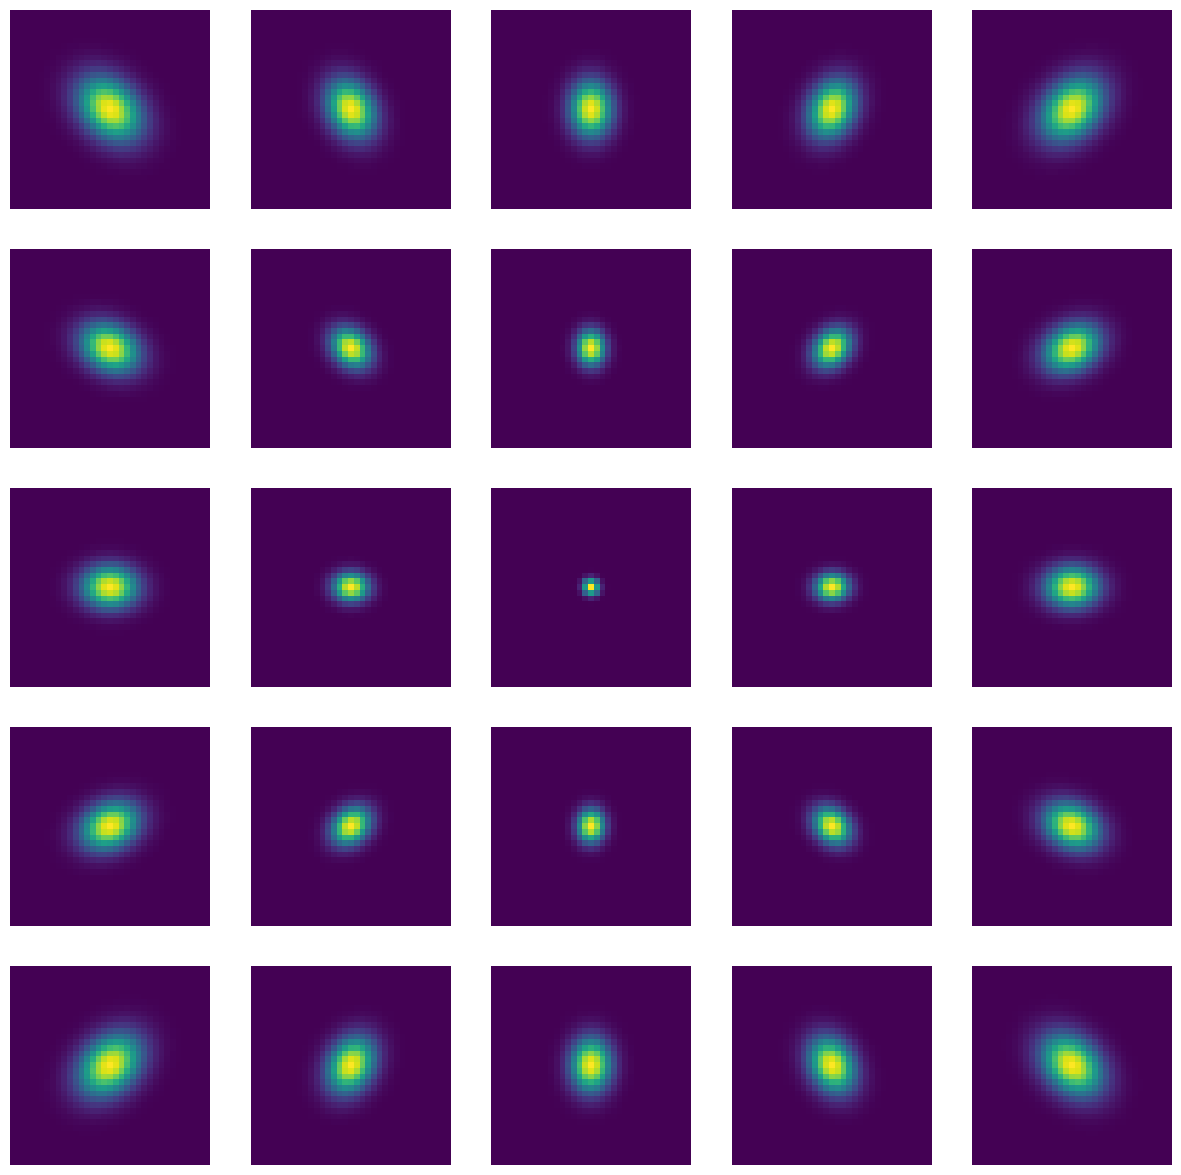

In [195]:
# test lat.sample

# create shapes
img_shape=(128,128)
sampled_shape=(5,5)

# define lattice
kernel_shape=(35,35)
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.3,'by':0.2,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)

# # sampled lattice into lattice_shape
sampled_lat=lat.sample(sampled_shape)

# plot results
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(15,15))

for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])())

img_shape= torch.Size([64, 64])
kernel_shape= (13, 13)
forward_timer= 6.9809153489768505


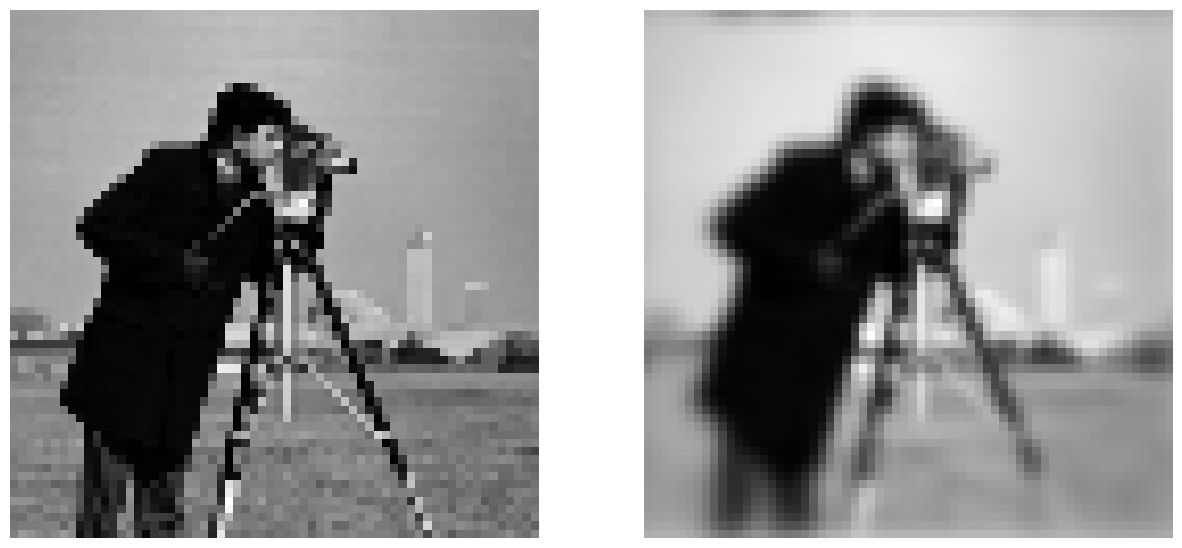

In [196]:
# NonstationaryBlur test (arallel forward) 

# resizer
resize = torchvision.transforms.Resize(size=(64))

# open test image
test_image=Image.open('../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(13,13)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.3,'by':0.2,'gamma_x':2,'gamma_y':2}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# define blur and apply
rgblur=blurtool.NonstationaryBlur(lat)
blurred_test_image=rgblur.forward(test_image,n_pool=4,debug=False)

# # results
fig,ax=plt.subplots(1,2,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')

print('forward_timer=',rgblur.forward_timer)

img_shape= torch.Size([64, 64])
kernel_shape= (13, 13)
forward_timer= 7.29961803695187


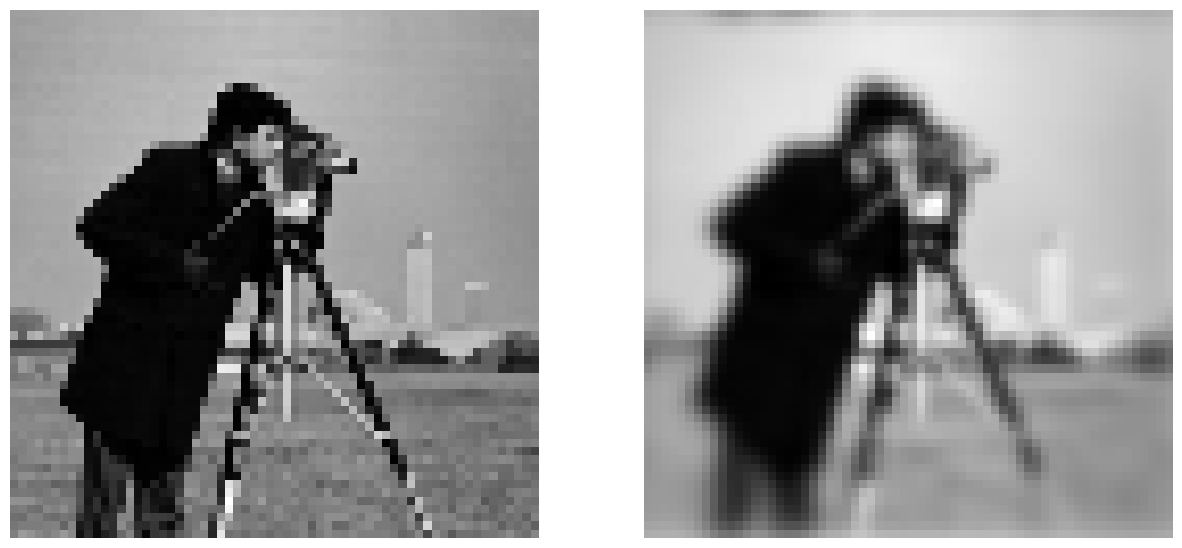

In [197]:
# # NonstationaryBlur test (linear forward) 

# resizer
resize = torchvision.transforms.Resize(size=(64))

# open test image
test_image=Image.open('../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=(test_image-torch.min(test_image))/(torch.max(test_image)-torch.min(test_image))
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(13,13)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.3,'by':0.2,'gamma_x':2,'gamma_y':2}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# define blur and apply
rgblur=blurtool.NonstationaryBlur(lat)
blurred_test_image=rgblur.forward(test_image,debug=False)

# # results
fig,ax=plt.subplots(1,2,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')

print('forward_timer=',rgblur.forward_timer)

plt.show()

stacked_kernels.shape= torch.Size([1225, 25])
stacked_kernel_shape= 1225
n_kernels= 25


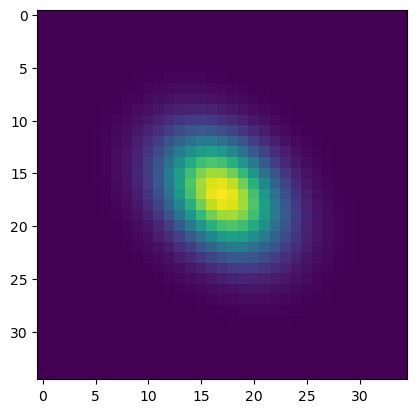

In [198]:
# test lat.stack_kernels in a sampled lattice

# create shapes
img_shape=(128,128)
sampled_shape=(5,5)

# define lattice
kernel_shape=(35,35)
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.3,'by':0.2,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)

# # sampled lattice into lattice_shape
sampled_lat=lat.sample(sampled_shape)

# results
print('stacked_kernels.shape=',sampled_lat.stack_kernels().shape)
print('stacked_kernel_shape=',kernel_shape[0]*kernel_shape[1])
print('n_kernels=',sampled_shape[0]*sampled_shape[1])
plt.imshow(sampled_lat.stack_kernels()[:,0].reshape(kernel_shape[0],kernel_shape[1]));

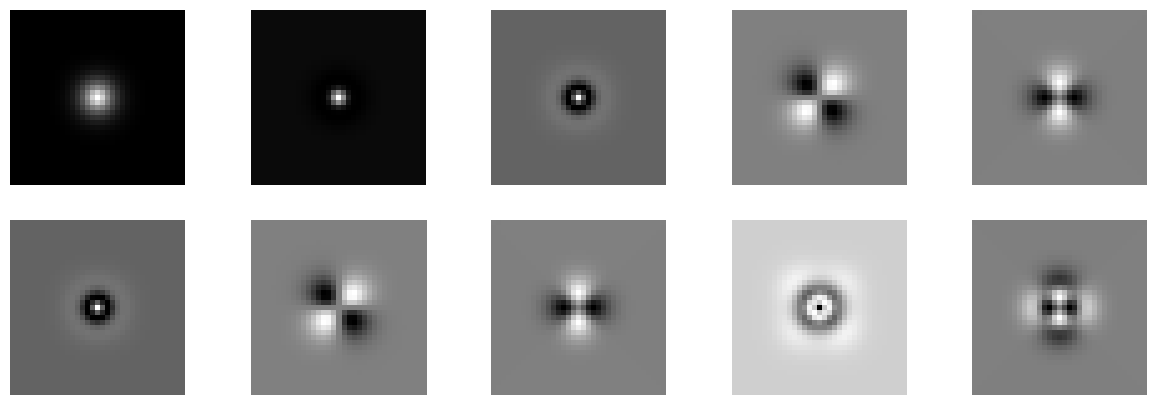

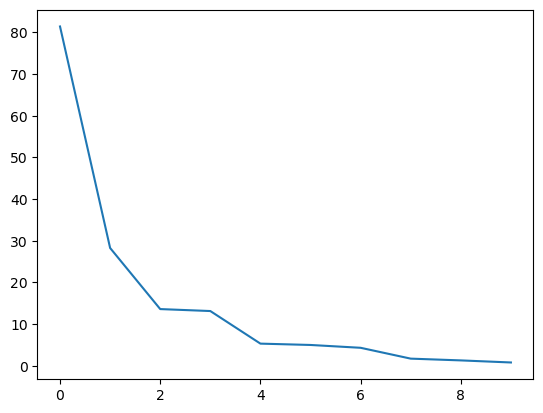

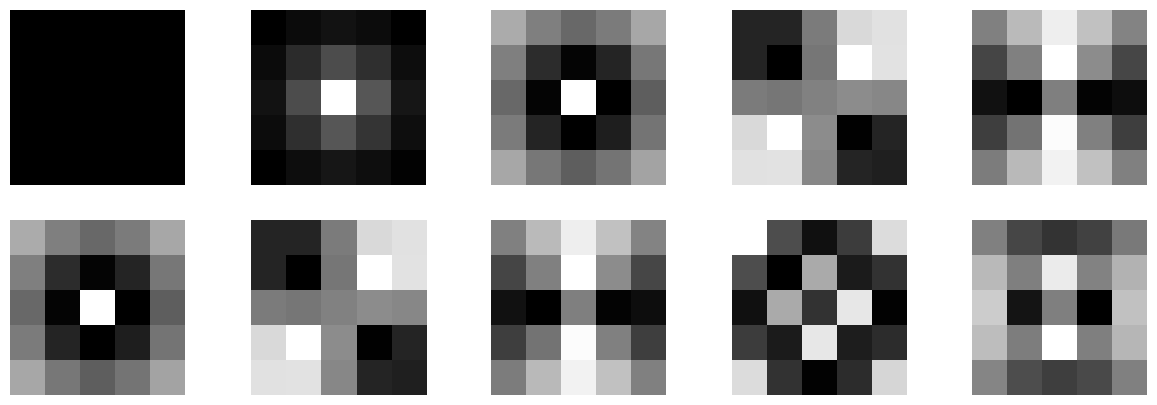

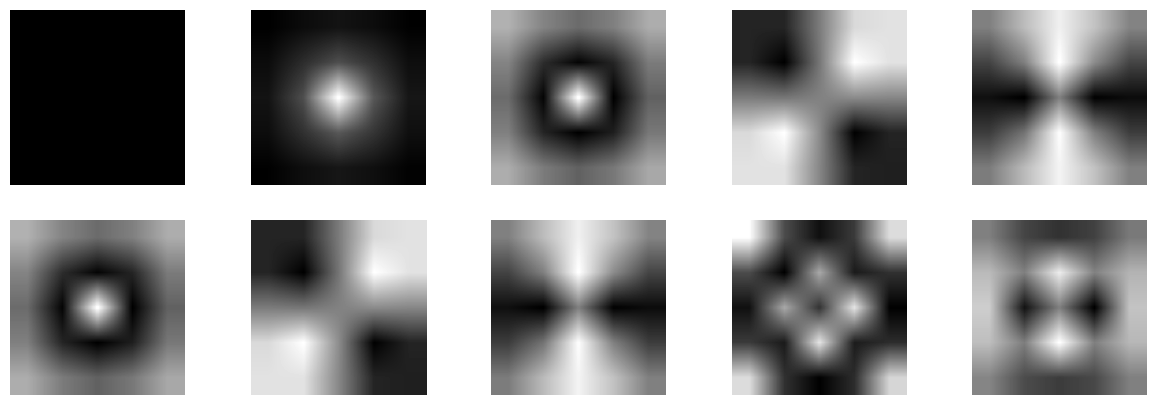

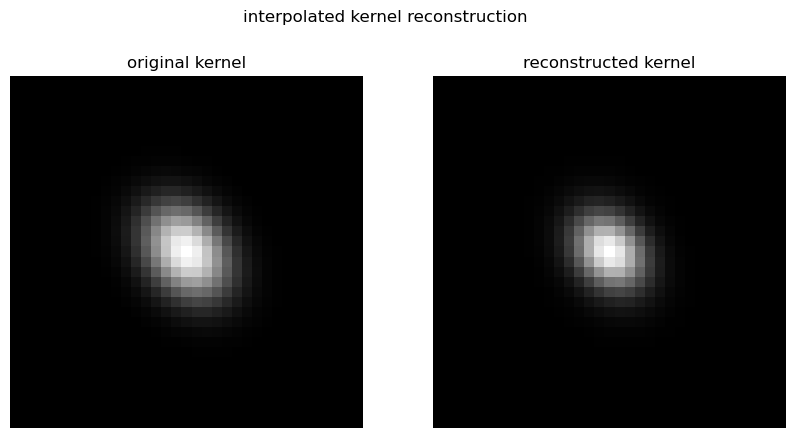

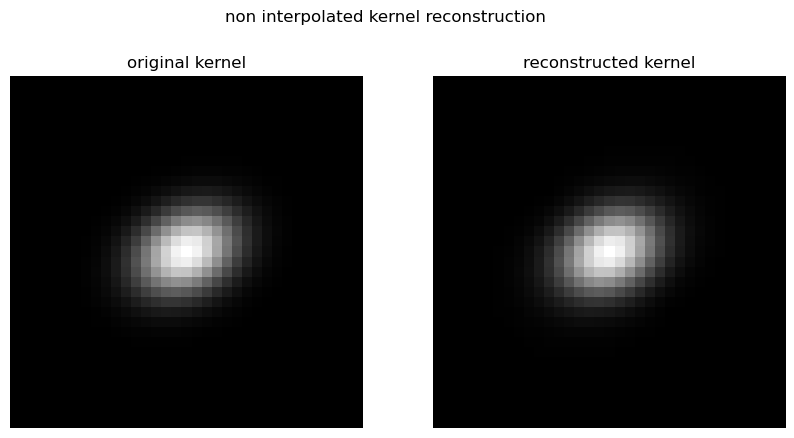

In [199]:
# create a lattice, sample it and decompose using pca

# shapes
img_shape=(128,128)
sampled_shape=(5,5)


# lattice creation
kernel_shape=(35,35)
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.3,'by':0.2,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)

# lattice sampling
sampled_lat=lat.sample(sampled_shape)

# decomposing
decompose_pars={'r':9}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=decompose_pars)

# results

# plot kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,5))
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()
        
# # plot vals
plt.plot(pca_lat.eigenvals)

# plot noninterpolated coefs
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,5))
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_eigencoefs[int(i*n_rows+j)],cmap='gray')
plt.show()

# plot coefs
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,5))
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigencoefs[int(i*n_rows+j)],cmap='gray')
plt.show()

# compare an arbitrary kernel of the original lattice with the same one in the decomposed lattice

pos=(100,90)
fig,ax=plt.subplots(1,2,figsize=(10,5))
fig.suptitle('interpolated kernel reconstruction')
ax[0].set_title('original kernel')
ax[0].axis('off')
ax[0].imshow(lat.kernel(pos)(),cmap='gray')
ax[1].set_title('reconstructed kernel')
ax[1].axis('off')
ax[1].imshow(pca_lat.kernel(pos)(),cmap='gray');

# compare an arbitrary kernel of the sampled lattice with the same one in the decomposed lattice
pos=(1,4)
fig,ax=plt.subplots(1,2,figsize=(10,5))
fig.suptitle('non interpolated kernel reconstruction')
ax[0].set_title('original kernel')
ax[0].axis('off')
ax[0].imshow(sampled_lat.kernel(pos)(),cmap='gray')
ax[1].set_title('reconstructed kernel')
ax[1].axis('off')
ax[1].imshow(pca_lat.noninterpolated_kernel(pos)(),cmap='gray');



img_shape= torch.Size([63, 63])
kernel_shape= (19, 19)
blur.forward_timer= 33.947979335905984
pca_blur.forward_timer= 0.025887646013870835
PSNR(blurred,pca_blurred)= tensor(35.3365, dtype=torch.float64)


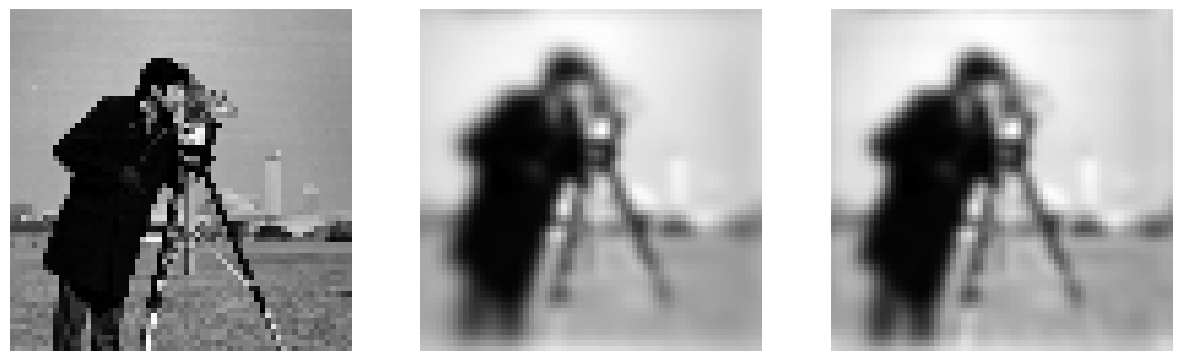

In [216]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(63))

# open test image
test_image=Image.open('../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(19,19)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.3,'by':0.2,'gamma_x':2,'gamma_y':2}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(5,5)
sampled_lat=lat.sample(sampled_shape)

# decompose sampled lattice
decompose_pars={'r':15}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=decompose_pars)

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
#pca_blur.decomposed=False # uncomment this to use the nondecomposed forward method

blurred_test_image=blur.forward(test_image,n_pool=4,debug=False)
pca_blurred_test_image=pca_blur.forward(test_image,n_pool=4,debug=False)

# results
fig,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))

img_shape= torch.Size([128, 128])
kernel_shape= (45, 45)
mu= tensor(0.5986) . lamb= 0.04 . rank= 0


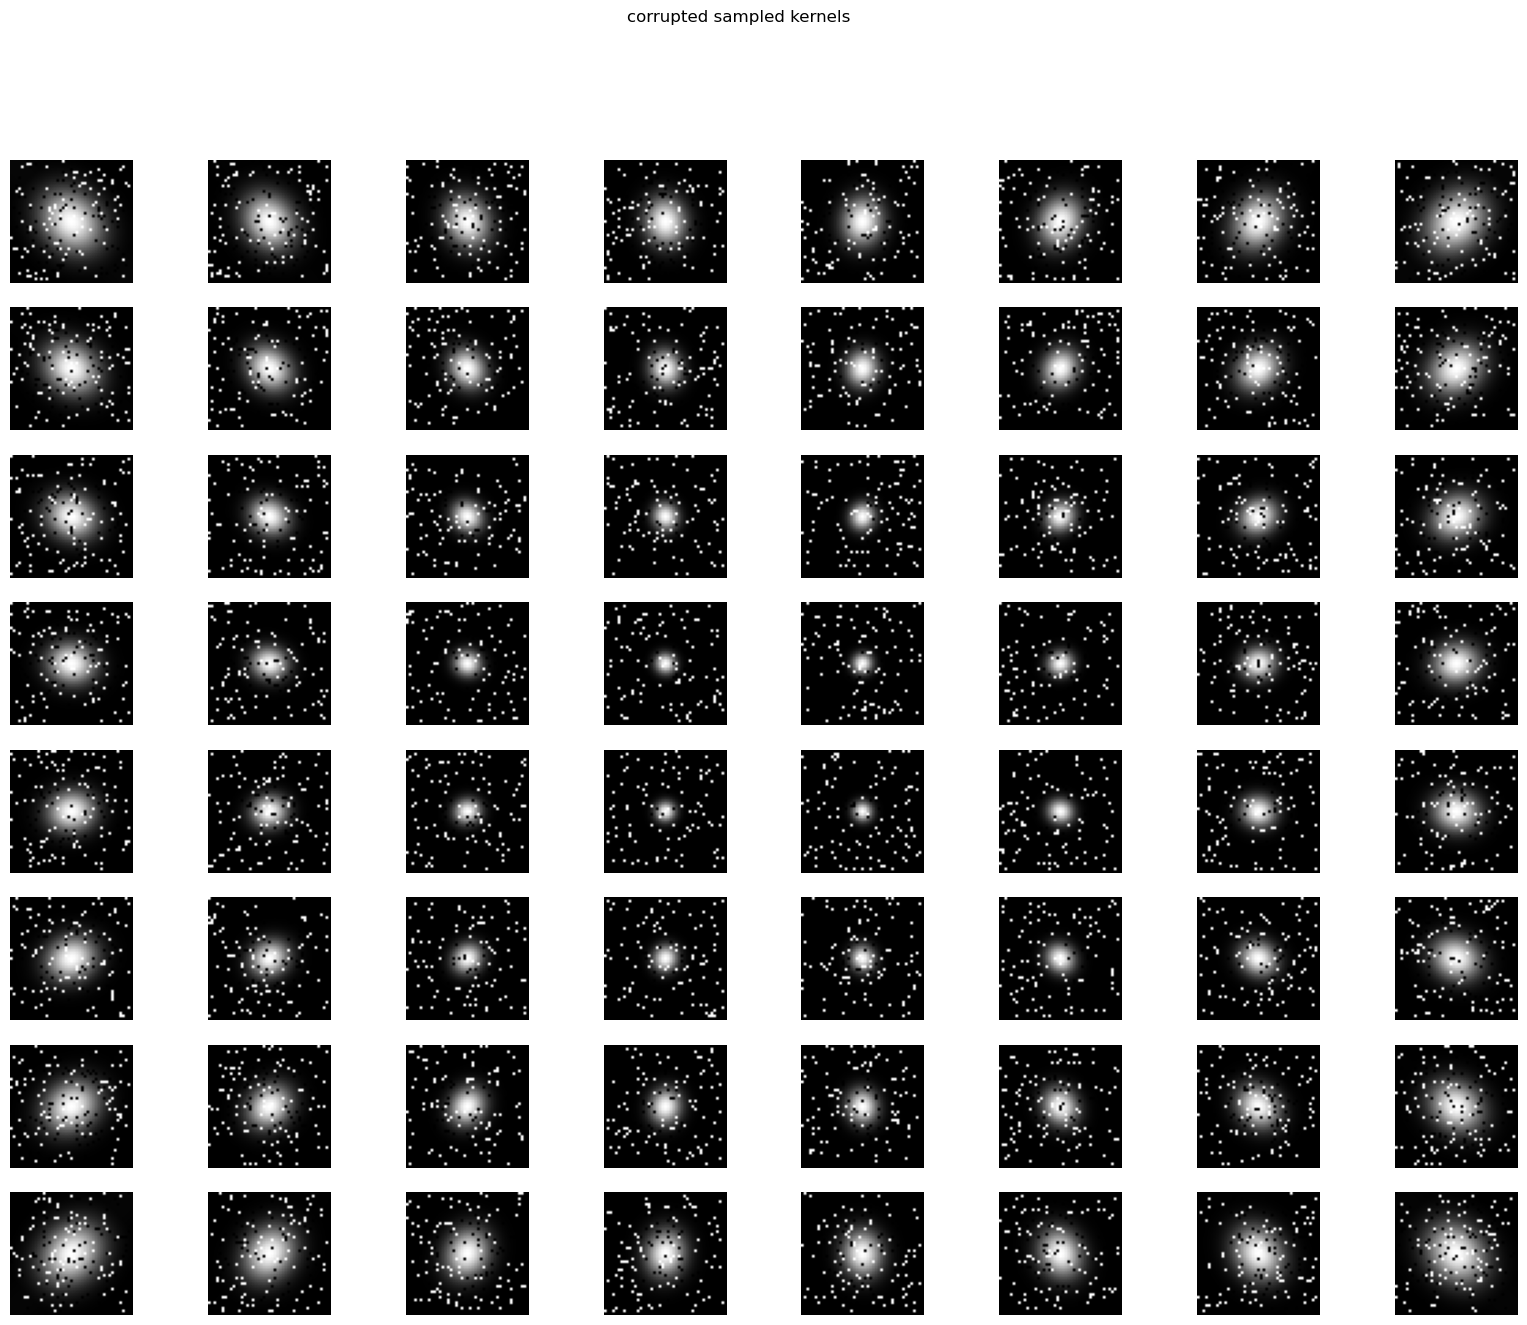

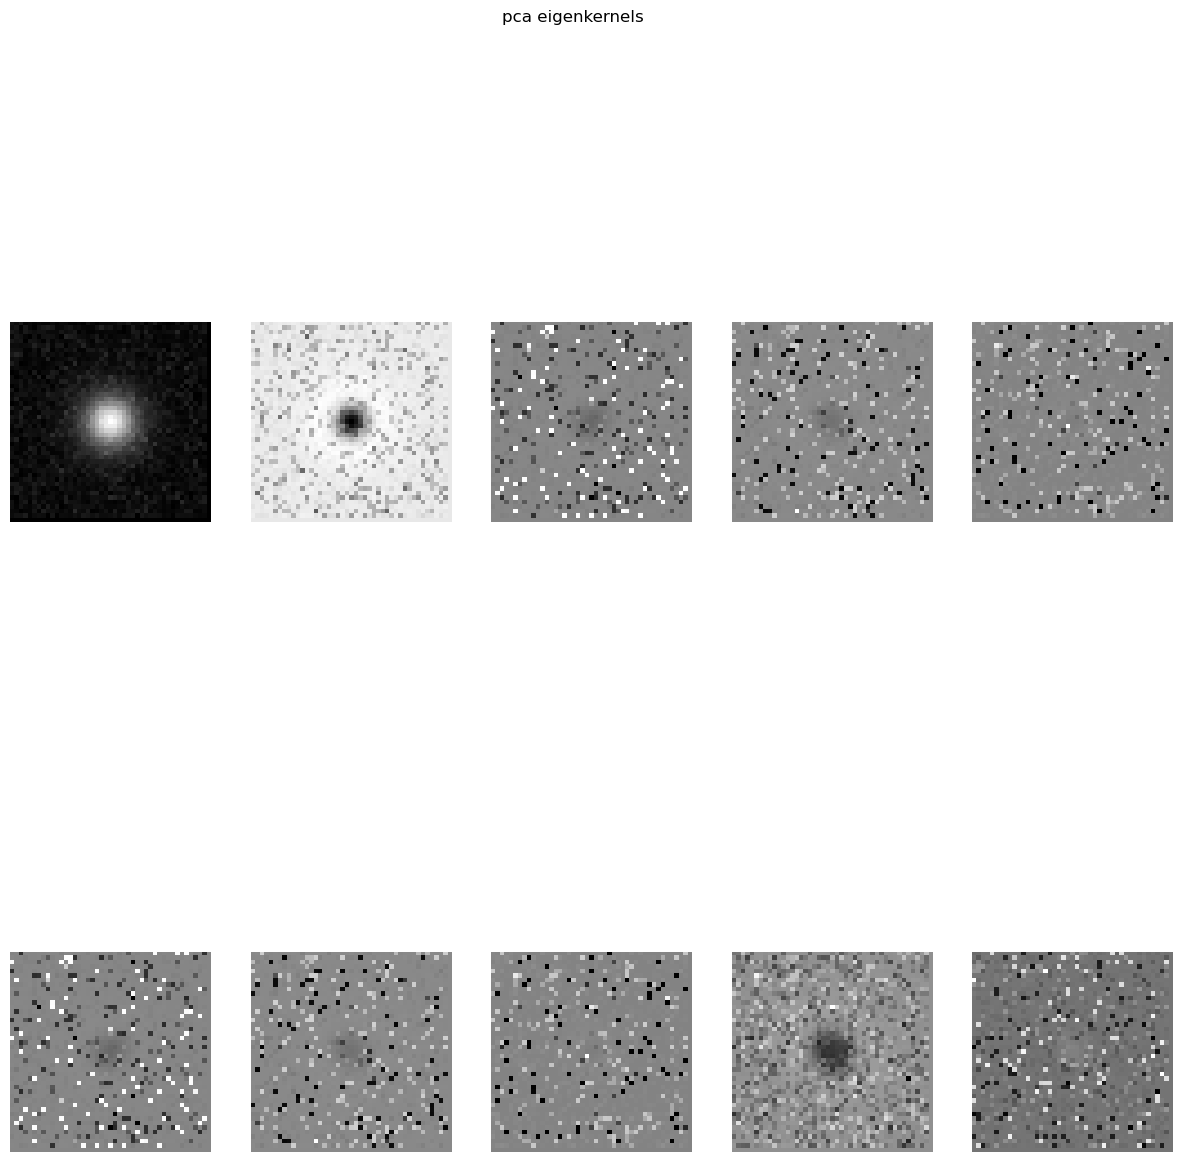

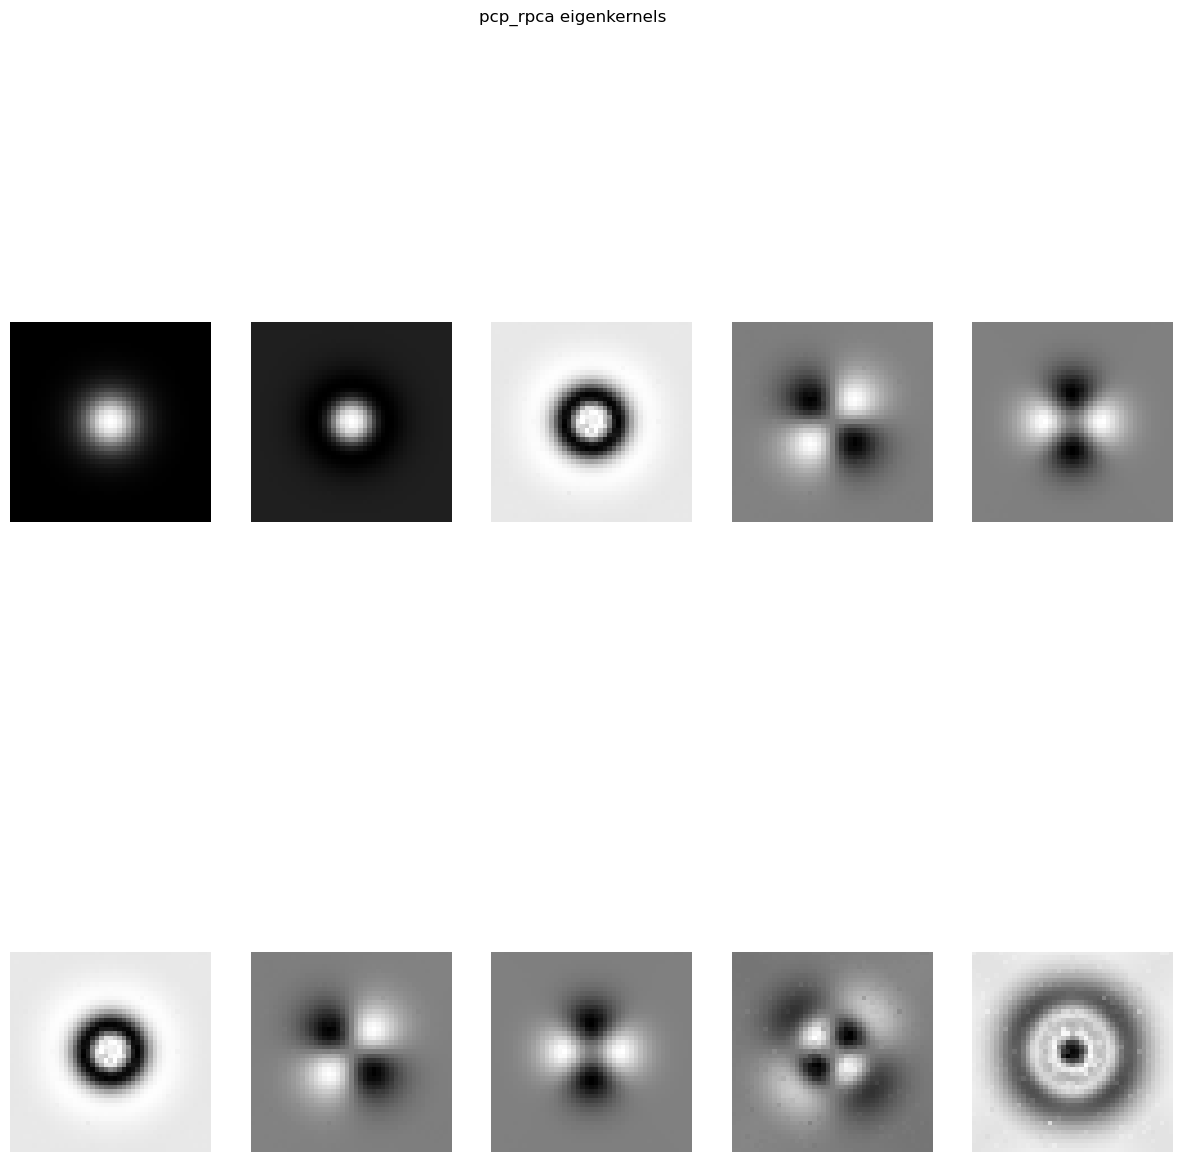

blur.forward_timer= 269.93842628900893
pca_blur.forward_timer= 0.022182697895914316
rpca_blur.forward_timer= 0.02201058086939156
PSNR(blurred,pca_blurred)= tensor(12.1983, dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(27.1235, dtype=torch.float64)


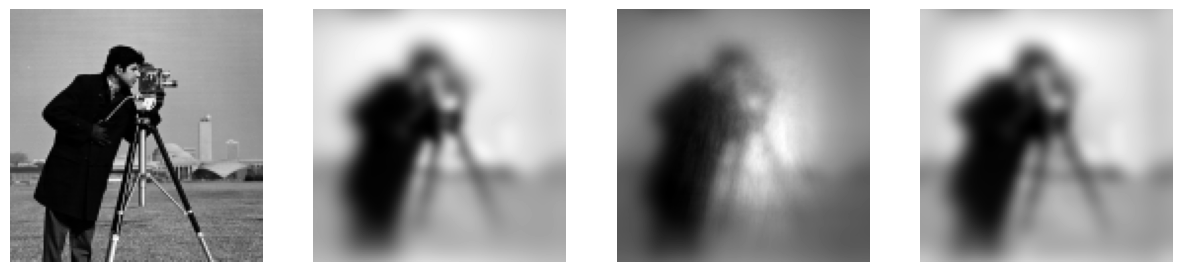

In [299]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(128))

# open test image
test_image=Image.open('../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(45,45)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.4,'by':0.3,'gamma_x':1.5,'gamma_y':1.5}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.1)
    
# decompose sampled lattice
r=10
pars_pca={'r':r}
pars_rpca={'lamb':0.04,'r':r,'tol':1e-20,'max_iter':1500,'debug':False} # lamb=0.04
# pars_rpca={'r':r,'debug':False}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)

# corrupted sampled  kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')

for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()

# plot pca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,15))
fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot pcp_rpca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,15))
fig.suptitle('pcp_rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

## blur a test image 

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
# pca_blur.decomposed=False
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)
# rpca_blur.decomposed=False

blurred_test_image=blur.forward(test_image,n_pool=4,debug=False)
pca_blurred_test_image=pca_blur.forward(test_image,n_pool=4,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,n_pool=4,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,5))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image,cmap='gray')

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))